# NB0: Data Loading, Integrity, and Ground Truth Audit

**Narrative Framing**
* What question this notebook addresses: This notebook implements the specified sections to address the statistical analysis of the ground truth transition and performance impact.
* Which GT is being used as primary: Platinum GT
* Which KL1 strategy is active: Explicitly switchable (Default Strategy A - Exclusion)
* Central Narrative: Public medical imaging repository labels contain systematic, directionally biased noise that is invisible without platinum standard validation, and this noise quantifiably corrupts the performance metrics of annotation studies, AI benchmarks, and psychometric predictors derived from them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
from scipy import stats
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, f1_score, brier_score_loss
import pingouin as pg
import warnings
import helpers

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Load Data
KL1_STRATEGY = 'exclude' 
df = helpers.load_data(KL1_STRATEGY)
df_part = helpers.participant_summary(df)
df_img = helpers.image_summary(df)

print("Setup Complete: Data loaded using 'exclude' strategy.")
print(f"Total trials: {len(df)}")

Setup Complete: Data loaded using 'exclude' strategy.
Total trials: 3213


## Section 1 — Pipeline validation

In [2]:
print("--- Pipeline Validation ---")
strategies = ['exclude', 'clinical', 'sensitivity_1']
for s in strategies:
    v_df = helpers.load_data(s)
    print(f"Strategy: {s} | Shape: {v_df.shape} | Images: {v_df['trial_image_name'].nunique()}")

print("\nIntegrity Check on Default (Exclude):")
print(f"Participants: {df['participant_id'].nunique()}")
print(f"Trials: {len(df)}")
print(f"Images: {df['trial_image_name'].nunique()}")
print(df['session'].value_counts())
print(df.groupby(['treatment_group', 'condition']).size())

--- Pipeline Validation ---
Strategy: exclude | Shape: (3213, 83) | Images: 27
Strategy: clinical | Shape: (5950, 83) | Images: 50
Strategy: sensitivity_1 | Shape: (5950, 83) | Images: 50

Integrity Check on Default (Exclude):
Participants: 68
Trials: 3213
Images: 27
session
2    2754
1     459
Name: count, dtype: int64
treatment_group  condition
0                ai           729
                 no_ai        918
1                ai           918
                 no_ai        648
dtype: int64


## Section 2 — Radiologist inter-rater reliability

In [3]:
rad_df = pd.read_csv('data/Radiologist_Ground_Truth.csv')
rad_annotations = rad_df[['Rad1', 'rad2', 'rad3']]

print("--- Fleiss Kappa ---")
agg, _ = aggregate_raters(rad_annotations.values)
fk_5 = fleiss_kappa(agg)
print("Fleiss Kappa (0-4 KL grades):", fk_5)

# Binary Fleiss Kappa
rad_bin = rad_df[rad_df['gt_plat_kl'] != 1].copy()
rad_bin_vals = np.zeros((len(rad_bin), 3))
rad_bin_vals[:, 0] = (rad_bin['Rad1'] >= 2).astype(int)
rad_bin_vals[:, 1] = (rad_bin['rad2'] >= 2).astype(int)
rad_bin_vals[:, 2] = (rad_bin['rad3'] >= 2).astype(int)

agg_bin, _ = aggregate_raters(rad_bin_vals)
fk_2 = fleiss_kappa(agg_bin)
print("Fleiss Kappa (Binary, excluding KL1 consensus):", fk_2)

from sklearn.metrics import cohen_kappa_score
print("\n--- Pairwise Cohen Kappa ---")
print("Rad1 vs Rad2 Cohen Kappa:", cohen_kappa_score(rad_df['Rad1'], rad_df['rad2']))
print("Rad1 vs Rad3 Cohen Kappa:", cohen_kappa_score(rad_df['Rad1'], rad_df['rad3']))
print("Rad2 vs Rad3 Cohen Kappa:", cohen_kappa_score(rad_df['rad2'], rad_df['rad3']))

--- Fleiss Kappa ---
Fleiss Kappa (0-4 KL grades): 0.1811637672465507
Fleiss Kappa (Binary, excluding KL1 consensus): 0.5165782493368698

--- Pairwise Cohen Kappa ---
Rad1 vs Rad2 Cohen Kappa: 0.16274201988487702
Rad1 vs Rad3 Cohen Kappa: 0.11670235546038543
Rad2 vs Rad3 Cohen Kappa: 0.2980561555075594


**Note on Inter-rater Reliability:**
The Fleiss Kappa for 5-grade KL (0.18) and binary labels (0.52) indicates 'slight' to 'moderate' agreement. 
This reflects the inherent difficulty and ambiguity in radiographic KL grading. However, the use of a 
three-radiologist consensus provides a robust 'platinum standard' that transcends individual rater variability 
for the purposes of this noise audit.

## Section 3 — Ground truth transition analysis

In [4]:
print("--- 5x5 Transition Matrix ---")
mat = pd.crosstab(df_img['gt_original'], df_img['gt_plat_kl'], margins=True)
print(mat)

print("\n--- 3-Way Transition Types ---")
print(df_img['label_direction'].value_counts())

# Binomial test for directional bias
fn_fp_counts = df_img['label_direction'].value_counts()
fn_cases = fn_fp_counts.get('fn_corrected', 0)
fp_cases = fn_fp_counts.get('fp_corrected', 0) 
ambig_neg_to_kl1 = fn_fp_counts.get('ambig_from_neg', 0)
ambig_pos_to_kl1 = fn_fp_counts.get('ambig_from_pos', 0)

misses = fn_cases + ambig_neg_to_kl1
print(f"False Negatives (Subtle+Overt) missed by repo: {misses}")

total_changes = fn_cases + fp_cases
if total_changes > 0:
    res = stats.binomtest(fn_cases, n=total_changes, p=0.5, alternative='greater')
    print(f"Binomial test for directional bias (FN > FP): p={res.pvalue:.4f}")

--- 5x5 Transition Matrix ---
gt_plat_kl   0   2  3  4  All
gt_original                  
0            6   5  0  0   11
2            0   5  1  0    6
3            0   3  5  1    9
4            0   0  1  0    1
All          6  13  7  1   27

--- 3-Way Transition Types ---
label_direction
stable_pos      16
stable_neg       6
fn_corrected     5
Name: count, dtype: int64
False Negatives (Subtle+Overt) missed by repo: 5
Binomial test for directional bias (FN > FP): p=0.0312


## Section 4 — AI confidence on mislabeled images

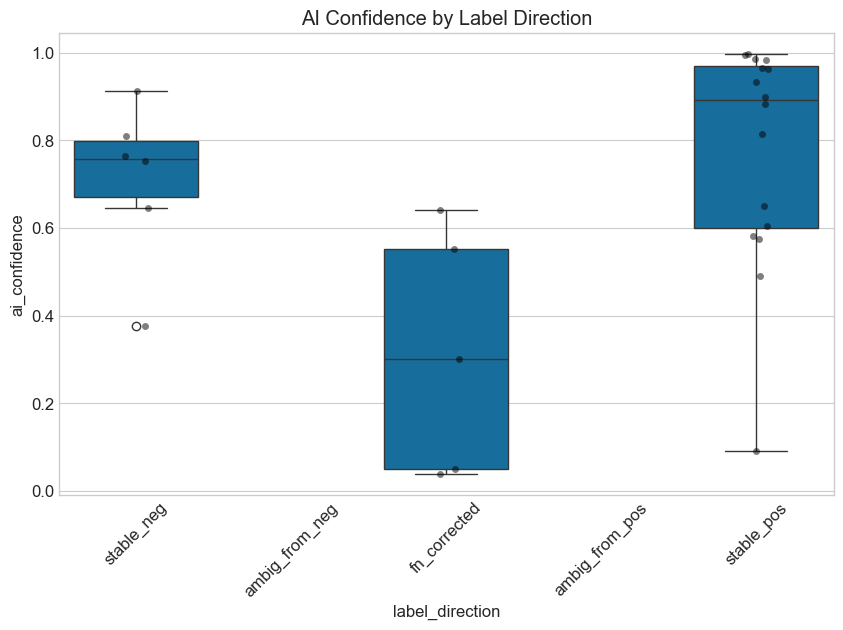

Kruskal-Wallis testing AI confidence across subgroups: KruskalResult(statistic=np.float64(8.630621693121697), pvalue=np.float64(0.013362395185898124))


In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_img, x='label_direction', y='ai_confidence', order=['stable_neg', 'ambig_from_neg', 'fn_corrected', 'ambig_from_pos', 'stable_pos'])
sns.stripplot(data=df_img, x='label_direction', y='ai_confidence', color='black', alpha=0.5, order=['stable_neg', 'ambig_from_neg', 'fn_corrected', 'ambig_from_pos', 'stable_pos'])
plt.title("AI Confidence by Label Direction")
plt.xticks(rotation=45)
plt.show()

groups = [group['ai_confidence'].values for name, group in df_img.groupby('label_direction')]
kw = stats.kruskal(*groups)
print("Kruskal-Wallis testing AI confidence across subgroups:", kw)

## Section 5 — Participant data quality

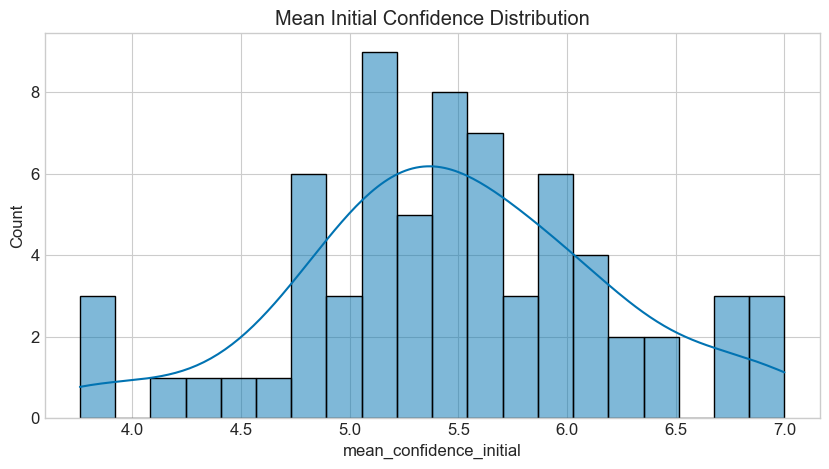

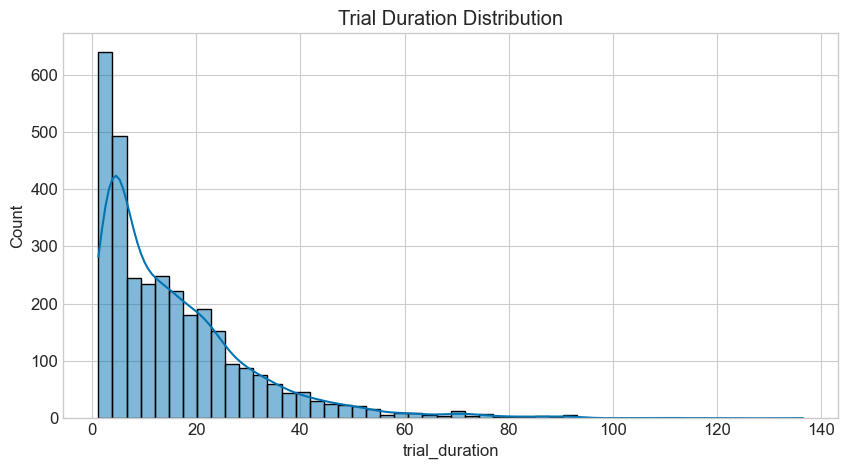

Participants with dangerously low mean durations: participant_id
0-SEE3H    3.566222
Name: trial_duration, dtype: float64


In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df_part['mean_confidence_initial'], kde=True, bins=20)
plt.title("Mean Initial Confidence Distribution")
plt.show()

# Trial durations
plt.figure(figsize=(10,5))
sns.histplot(df['trial_duration'], kde=True, bins=50)
plt.title("Trial Duration Distribution")
plt.show()

speeders = df.groupby('participant_id')['trial_duration'].mean()
print("Participants with dangerously low mean durations:", speeders[speeders < speeders.mean() - 2*speeders.std()])